# PropertyScan: project report

**A walkthrough of the whole take-home, for anyone who wants the picture without reading the code.**

- **Assignment:** Applied AI Engineer case study. Phone capture → dimensioned, stitched whole-property floor plan, with damage, scope and uncertainty, from three input tiers (photos, video, LiDAR).
- **Repo:** https://github.com/dhanoliya-ji/PropertyScan-AI
- **Built in one day** (about 10:45–17:35 IST, 4 Oct 2026), within the 48-hour window.

Every number in this notebook is read from files that `scripts/benchmark.py` regenerates from the raw captures. Nothing is typed in by hand except where a section says so.

| Section | Content |
|---|---|
| 1 | Status at a glance |
| 2 | Constraints we worked under (hardware, ground truth, compute) |
| 3 | The data we had |
| 4 | Architecture: one engine, three tiers, with block diagrams |
| 5 | Design decisions and the evidence behind them |
| 6 | Results: plans, gates, repeatability, drift, cross-tier, damage, timing |
| 7 | Fix loop |
| 8 | What is not done, and why |
| 9 | Known failure modes |
| 10 | Defence notes: likely questions and answers |
| 11 | How to reproduce |
| 12 | Build timeline (commit history) |

## 1. Status at a glance

| Area (assignment part) | Built? | Measured result | Status |
|---|---|---|---|
| Capture route (Part 1): Route 2, stock apps + one-page protocol | Yes | `docs/CAPTURE_PROTOCOL.md` | Done |
| Photo tier: per-room folders → stitched whole-property plan | Yes | stitches with correct adjacency and no overlaps, but recovers 4/7 rooms | Runs; gate fails |
| Video tier: handheld walkthrough | Yes | 59% median wall error vs LiDAR | Runs; gate fails |
| LiDAR tier: depth + poses + intrinsics | Yes | sensible multi-room plans, doors, mirrors rejected | Works |
| Output contract (Part 2): walls, ceiling, area, openings, stitched plan, damage, concealed flags, scope, CI on every number, JSON schema, rendered plan, one command | Yes, all of it | see §6 | Done |
| Drift accountability + on/off ablation | Yes | pose graph with ICP loop closures; ghost-wall area −7% on `with_ceiling` | Done |
| Repeatability gate (1 cm / 0.5%) | Measured | 0% within the gate on the final benchmark | Fails |
| Head-to-head vs Polycam/magicplan (Part 3) | **No** | needs an iPhone scan of the same rooms | **Not done** (§2, §8) |
| Fix loop (Part 4) | Yes | 0% → 14.3% within the gate, p90 66 → 51 cm; gate still fails | Done, honestly reported |
| Process evidence (Part 5) | Yes | 13 incremental commits with measured numbers | Done |
| Deliverables: compliance matrix, README, reproduction bundle, benchmark report, technical report ≤ 6 pages, raw data | Yes | `docs/`, `benchmark/` | Done |

**In one line:** every component the PDF asks for exists and runs end to end. The accuracy gates mostly fail or can't be measured, because we had no iPhone and no ground truth, and that's stated wherever it applies.

## 2. Constraints we worked under

These shaped every decision. They're listed first so no result below reads as a hidden excuse.

### 2.1 No iPhone or LiDAR hardware
The assignment assumes the candidate owns or can borrow an iPhone 15+ (Pro for LiDAR). **I have no iPhone.** That directly blocks:
- **Part 3, the head-to-head vs Polycam/magicplan:** it needs a scan of the same rooms with the consumer app. Not done.
- **Building our own benchmark set:** our own multi-room capture, a furnished room with staged damage, a room captured twice under the same protocol, and real per-room photo folders. Not possible.
- **Route 1 (own iOS app):** it needs a Mac, Xcode and an iPhone, so Route 2 (stock apps + protocol) was the only option. Route 2 is a legitimate route in the brief.
- **Rehearsing the walk-in test** on a phone of our own.

### 2.2 No ground truth
The three sample captures came **without laser or tape measurements**, so no number here is "accuracy vs truth". Instead, the benchmark measures what the data can support, and labels everything else NOT MEASURED:
1. **Repeatability:** two LiDAR captures of the same apartment compared to each other.
2. **Cross-tier agreement:** the video and photo tiers compared to the LiDAR tier of the *same* capture, with both tiers' σ in the interval test.
3. **Synthetic damage injection** of known size, painted onto a real wall consistently across views.

### 2.3 Compute and time
- A Windows laptop, 12-thread CPU, RTX 3050 4 GB. PyTorch was CPU-only, and installing CUDA PyTorch (about 2.5 GB) was impractical on the available connection: 100 MB of model weights took about 5 minutes.
- The depth model runs at about 1.3 s per frame on CPU. The video tier is therefore slow (47 minutes on the longest clip without cache).
- In the afternoon the laptop ran about 6× slower than in the morning (likely thermal or power throttling), which inflates the timing table.
- One working day.

### 2.4 Sample data instead of our own captures
The recruiter's email says "please run your code on this Sample Data", while the PDF says "we provide no captures". We treated the sample data as the benchmark and derived the video and photo inputs from it (§3). This is disclosed everywhere it matters.

## 3. The data we had

Three **Stray Scanner** exports (iPhone Pro LiDAR logging app) of one apartment:

| Capture | Length | Frames | Path walked | Start–end gap (drift indicator) | Content |
|---|---|---|---|---|---|
| `single_room.zip` | 37 s | 1,715 | 14.5 m | 3.18 m (doesn't return to start) | living area + bathroom |
| `single_scan_floor_only.zip` | 115 s | 5,251 | 54 m | 0.17 m | whole apartment, camera mostly on walls and floor |
| `single_scan_with_ceiling.zip` | 215 s | 9,745 | 100 m | 0.39 m | whole apartment, including ceilings, mirrors, glass shower |

Each export contains:
- `rgb.mp4`: 1920×1440 video;
- `depth/*.png`: 256×192 depth in mm;
- `confidence/*.png`: confidence 0–2;
- `odometry.csv`: ARKit pose and intrinsics per frame;
- `camera_matrix.csv`;
- `imu.csv`.

**How each tier's input was made from this:**
- **LiDAR:** the zip as-is.
- **Video:** only `rgb.mp4`. No depth, no poses, no IMU.
- **Photos:** `scripts/make_photo_benchmark.py` picks frames from the video the way a person following the protocol would (an overlapping sweep per room, plus a `door_to_<room>.jpg` aimed at each doorway). It writes them as JPEGs with the iPhone's 35 mm-equivalent focal length in EXIF. The LiDAR plan is used only to choose which frames; the photo pipeline never sees depth or poses. **Limitation:** video frames are softer than real iPhone stills, so this is a harder-than-real photo benchmark.

**A fact we verified rather than assumed:** Stray's pose convention. With the textbook ARKit→OpenCV axis flip, the fused floor smears over 2 m. With the raw pose it collapses into a single 1 cm bin holding 6% of all points. The loader documents this.

## 4. Architecture: one engine, three tiers

```
capture ──► tier front-end ──► FrameSet {depth_i, mask_i, K_i, pose_i} ──► shared geometry engine ──► PropertyScan JSON + plan PNG/SVG
             lidar  : Stray depth + confidence + ARKit poses       drift pose graph → fuse (2 cm voxels + normals)
             video  : monocular metric depth + our own tracking     → gravity + Manhattan alignment
             photos : monocular depth + per-room registration       → floor/ceiling levels → 2D occupancy
                      + door-photo stitching                        → rooms (watershed) → walls (plane fit)
                                                                    → openings → intervals → damage / rules / scope
```

**The main design decision:** every tier reduces to *metric depth plus a camera pose per frame*. Walls, rooms, openings, uncertainty and damage share one code path. Tiers differ only in where depth and poses come from, and in the error budget attached to them. This keeps the walk-in test to one engine to debug, and one design to defend.

| Module | What it does |
|---|---|
| `propscan/io/stray.py` | Stray loader (zip or folder), pose convention verified on data |
| `propscan/tiers/lidar.py`, `video.py`, `photos.py` | tier front-ends → FrameSet |
| `propscan/models/depth.py` | Depth Anything V2 Metric-Indoor (small), own preprocessing (no torchvision), deterministic on-disk cache |
| `propscan/geometry/frames.py` | back-projection, per-pixel normals, voxel fusion |
| `propscan/geometry/drift.py` | fragment pose graph + ICP loop closures |
| `propscan/geometry/align.py` | gravity (from normals when no IMU) + Manhattan yaw |
| `propscan/geometry/plan.py` | levels, occupancy, room segmentation, wall fit, doors, windows, mirror rejection |
| `propscan/uncertainty.py` | per-tier error budget → 95% interval on every measurement |
| `propscan/damage/detect.py` | damage regions, concealed-damage rules R1–R5, scope line items |
| `propscan/schema.py` → `schema/property_scan.schema.json` | published output contract |
| `propscan/render.py` | dimensioned floor plan PNG/SVG |
| `propscan/compare.py` | registers two plans and matches rooms, walls and openings (used for scoring) |

**One command per capture:** `python -m propscan run <capture> -o out/`. The tier is detected automatically: a `.zip` or Stray folder is LiDAR, a `.mp4`/`.mov` is video, a folder of room folders is photos.

### 4.1 Block diagrams

**System overview:** three capture types → tier front-ends → a common FrameSet → the shared engine → outputs.

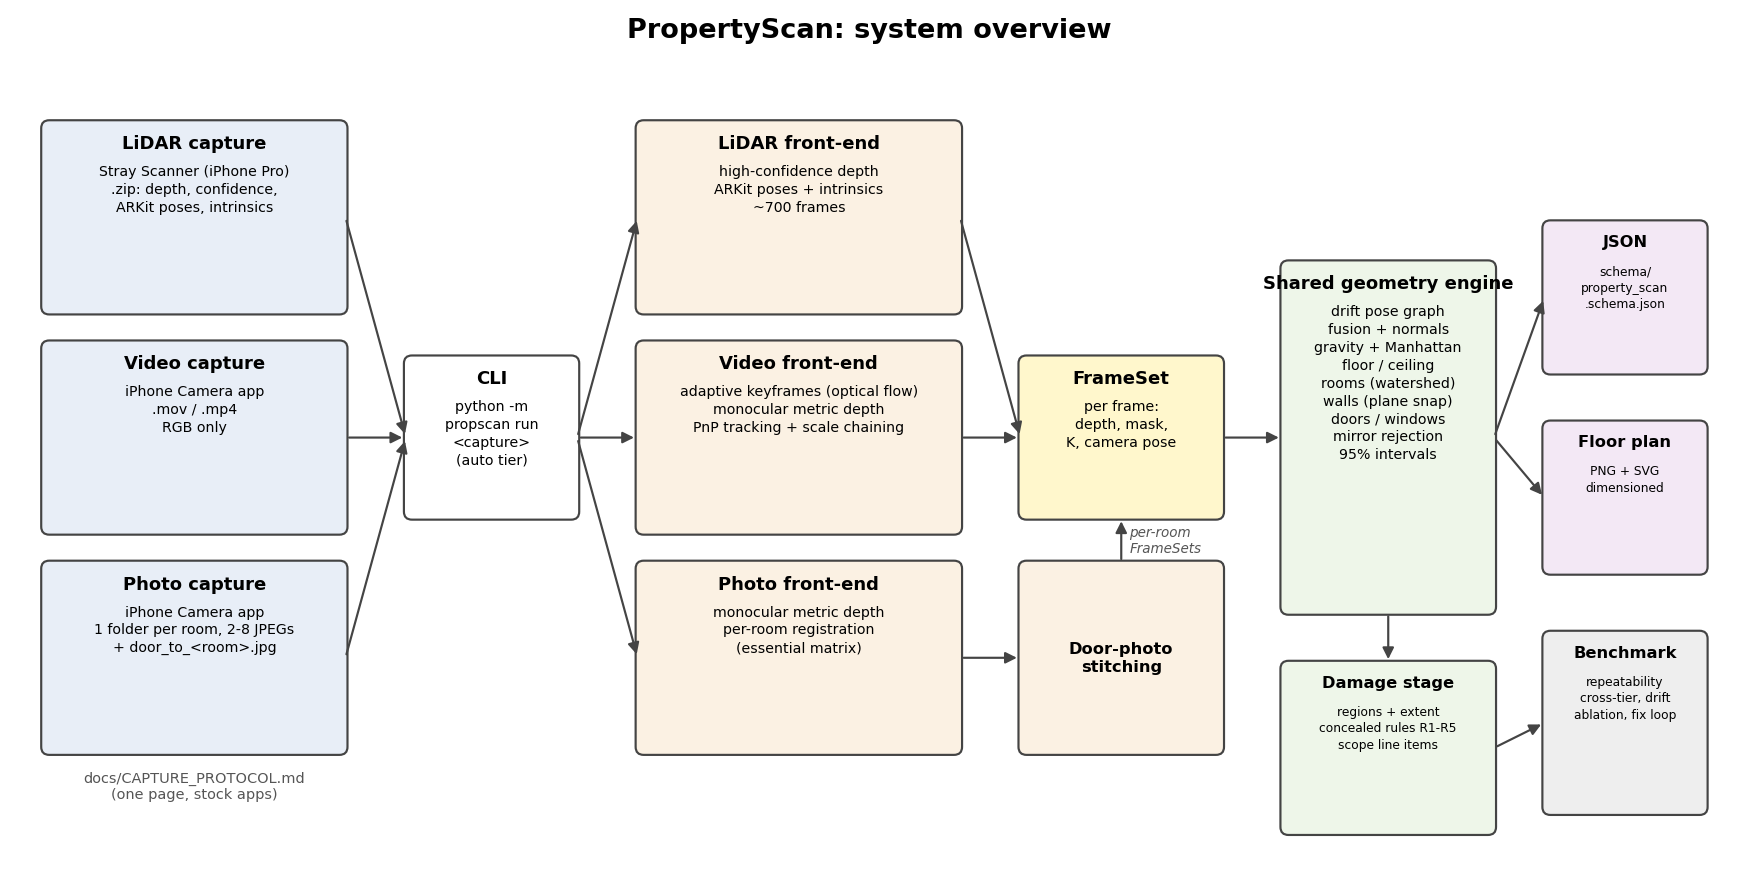

In [1]:
from IPython.display import Image
Image(filename="docs/img/diagram_system.png", width=1000)

**Tier front-ends:** how each input type becomes a FrameSet (depth + pose per frame).

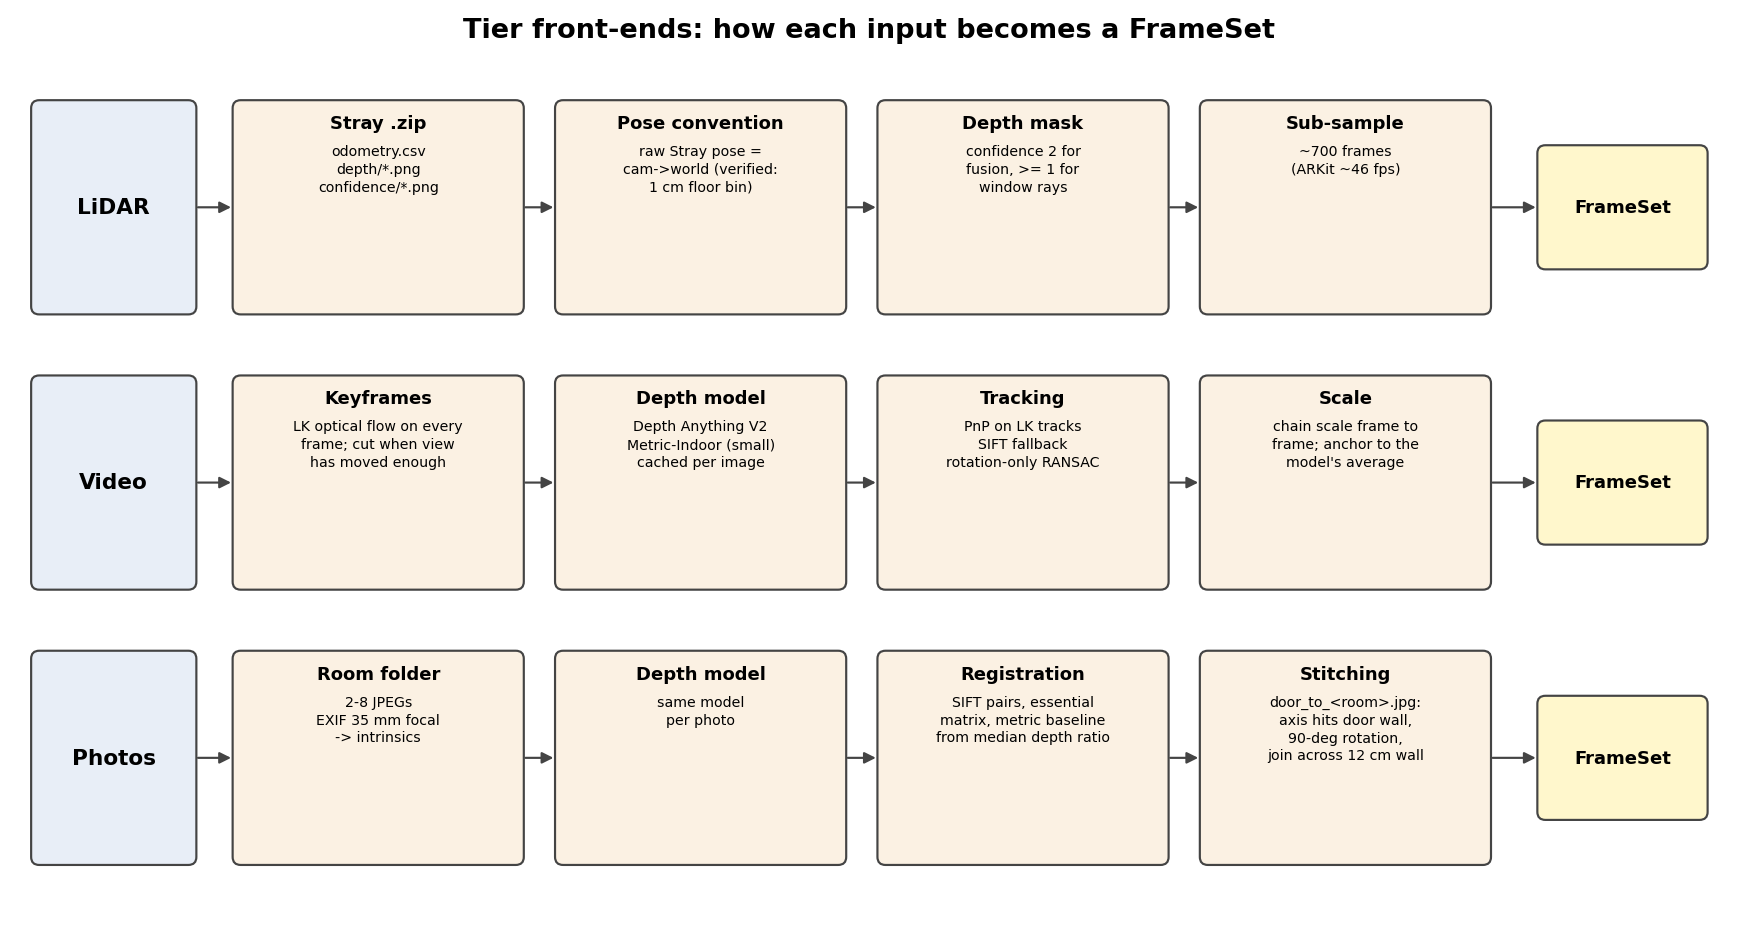

In [2]:
Image(filename="docs/img/diagram_tiers.png", width=1000)

**Shared geometry engine:** the ten stages every tier goes through.

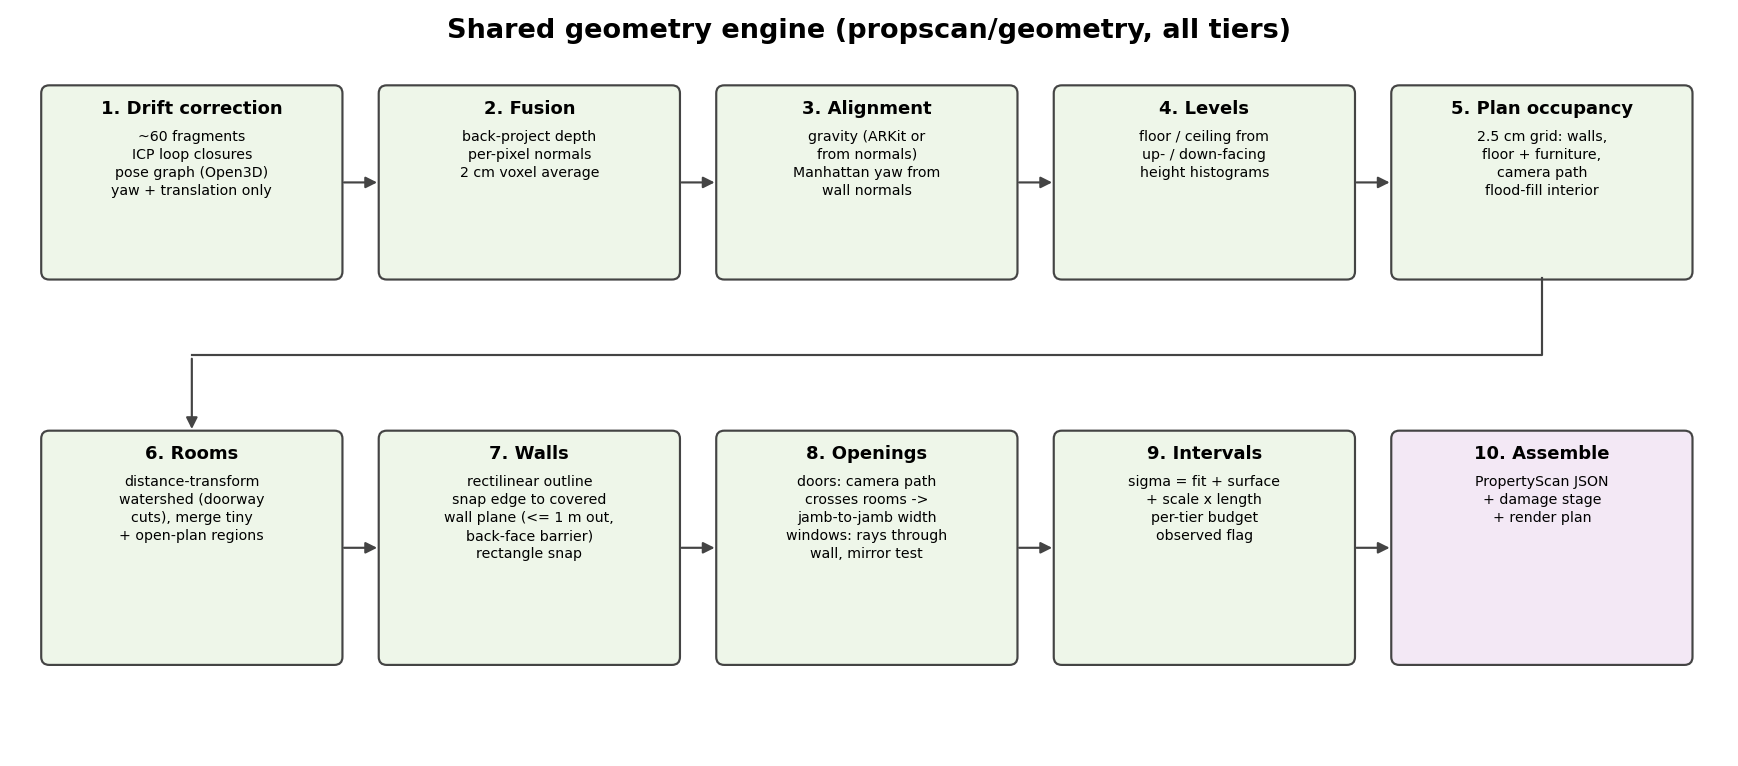

In [3]:
Image(filename="docs/img/diagram_engine.png", width=1000)

**Evaluation:** with no ground truth, what the benchmark measures instead, and how it feeds the fix loop.

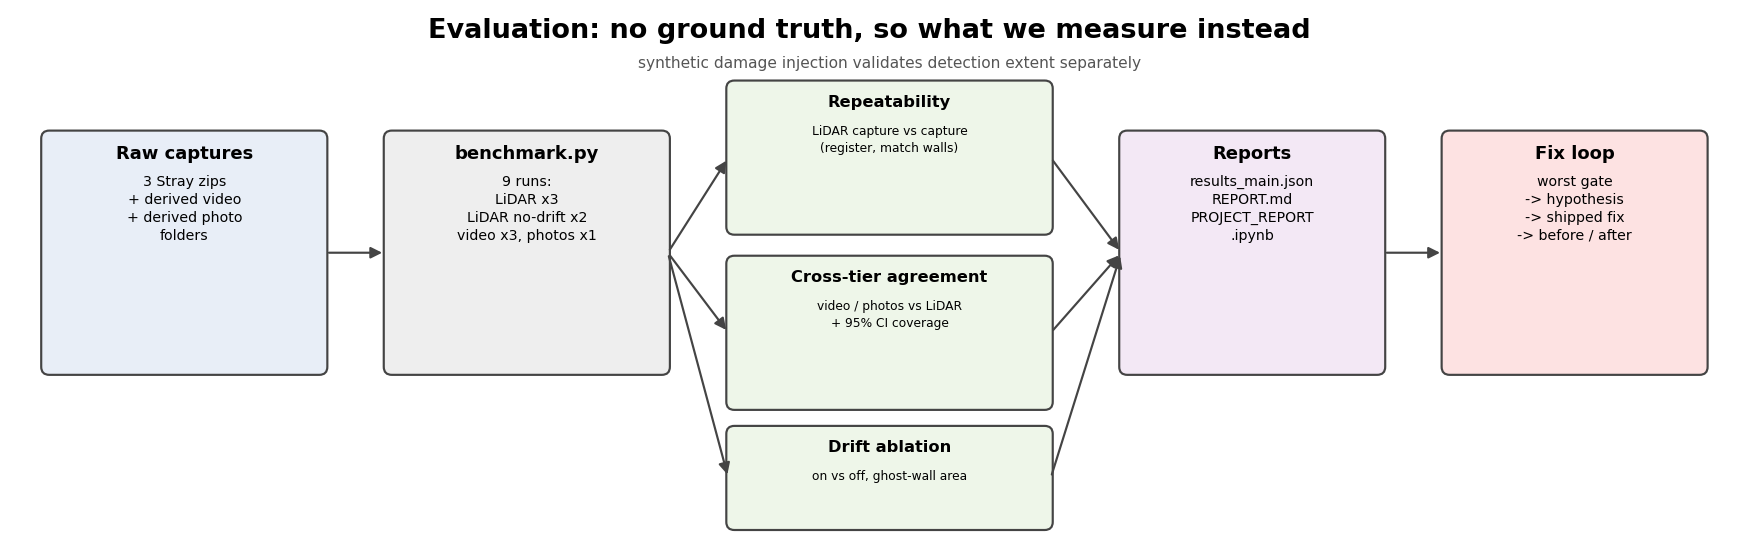

In [4]:
Image(filename="docs/img/diagram_evaluation.png", width=1000)

## 5. Design decisions and the evidence behind them

### 5.1 Engine steps (all tiers)
1. **Floor and ceiling:** histogram peaks of up-facing and down-facing points; each room is then refined on its own.
2. **2.5 cm plan grid:**
   - *wall evidence:* points with horizontal normals, 0.12–2.2 m above the floor;
   - *interior evidence:* floor, furniture and the camera path;
   - the interior is a **flood fill from the camera path**, bounded by walls, with holes filled so furniture footprints count as floor.
3. **Rooms:** a distance-transform **watershed** with seeds where clearance is over 0.42 m, so doorways become cuts. Fragments under 1.2 m² are merged, and shared boundaries over 1.6 m are treated as open plan.
4. **Walls:** a rectilinear polygon per room. Each edge is snapped to the room-facing wall plane that **covers most of the edge**, searching up to 1 m outward and capped by the back face of our own wall (this came out of the fix loop, §7). Near-rectangular rooms snap to rectangles.
5. **Doors between rooms:** found **where the camera path crosses from one room into another**, then measured between the jamb points.
6. **Windows and doors to unscanned space:** cells of a wall that camera **rays pass through** (a return more than 35 cm beyond the plane) and that hold no wall return.
7. **Mirror rejection:** reflect a gap's through-returns back across the wall plane. If more than 50% land on real geometry, it's a mirror. This fired 5 times on the sample apartment (bathroom mirrors, glass shower).

### 5.2 LiDAR tier
- Only high-confidence depth (≥ 2) is fused, up to 4.5 m.
- Medium confidence (≥ 1) up to 8 m is used for the ray test.
- ARKit poses go through drift correction.

### 5.3 Video tier: why scale is chained, not trusted
Measured against LiDAR, monocular depth gets the **shape** right (2.6% median error after per-frame scaling), but its **per-frame metric scale wanders 0.3× to 1.4× within seconds**. So:
- scale is **chained geometrically** from frame to frame, comparing the model depth with the depth of points carried over by the estimated pose, and anchored once to the model's average scale;
- **keyframes are adaptive:** Lucas-Kanade optical flow runs on every frame, and a keyframe is cut when the view has moved enough, so fast pans get dense keyframes;
- those flow tracks feed PnP, with SIFT as fallback and a rotation-only RANSAC for whip-pans.

Diagnostic against the ARKit trajectory, used only as a reference (`scripts/diag_video_tracking.py`): tracked keyframes 41/75 → 287/314, trajectory RMSE 1.27 → 0.79 m over a 14 m walk. Still far from the ±3% gate.

### 5.4 Photo tier: why the essential matrix, not PnP
Per-point monocular depth errors break PnP: it registered **2 of 11** photos in a room. The essential matrix doesn't need depth for rotation and translation direction, and the metric baseline then comes from a *median* ratio of model depth to triangulated depth. That registered **9 of 11**.

**Stitching is designed into the protocol.** Each room folder contains `door_to_<room>.jpg`, taken from inside the room and centred on the doorway. Its optical axis hits the door wall, which gives the door's position in both rooms. The rooms are rotated by multiples of 90° so the door walls face each other, then joined across a 12 cm wall. Overlaps are checked.

### 5.5 Drift correction
1. Cut the trajectory into about 60 fragments.
2. Register each consecutive pair and the nearest overlapping fragments with point-to-plane ICP (15 → 6 → 3 cm).
3. Optimise an Open3D pose graph with outlier pruning.
4. **Keep only yaw and translation** from each correction: ARKit gravity is reliable, and correcting roll or pitch only adds noise.
5. Interpolate the corrections along the path.

### 5.6 Uncertainty (on every measurement)
σ = sqrt(σ_fit,a² + σ_fit,b² + 2·σ_surface² + (s_rel·L)²)

| Tier | σ_surface | s_rel (scale) |
|---|---|---|
| LiDAR | 6 mm | 0.3% |
| Video | 2 cm | 3% |
| Photos | 4 cm | 7% |

- **Unobserved walls:** widened ×2 and flagged `observed: false`.
- **Unscanned ceilings:** a prior (at least the highest wall point), σ = 12 cm, flagged `observed: false`.

### 5.7 Damage, concealed-damage rules and scope
- **Detector:** classical and weight-free, restricted to pixels within 3 cm of a measured wall or ceiling, so furniture never counts.
  - *Stains:* diffuse, low-contrast, warm-hued blobs.
  - *Mould:* dense clusters of small, low-saturation spots.
  - *Cracks:* thin dark lines not aligned with the walls' horizontal/vertical axes.
  - *Holes:* LiDAR recesses 3–8 cm deep with an on-plane surround.
  - Every detection must repeat in at least 3 views.
- **Concealed-damage rules R1–R5:** e.g. a water stain on a ceiling → leak above. Each flag stores the rule text that fired.
- **Scope line items:** keyed to surface IDs, e.g. crack fill, stain-block primer, mould remediation, full-surface repaint, moisture survey.
- **Tuning:** on the undamaged apartment, false positives went from 34 to 0. They were fridge magnets, wardrobe handles and tile grout.

In [5]:
import json, pathlib
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = pathlib.Path.cwd()
if not (ROOT / "benchmark").exists():      # allow running from scripts/
    ROOT = ROOT.parent
R = json.loads((ROOT / "benchmark" / "results_main.json").read_text())
FL = json.loads((ROOT / "benchmark" / "fixloop_eval.json").read_text())
SYN = json.loads((ROOT / "benchmark" / "synthetic_damage.json").read_text())
pd.set_option("display.width", 200)
print("loaded:", ", ".join(R.keys()))

loaded: repeatability_lidar_floor_vs_ceil, repeatability_lidar_room_vs_ceil, repeatability_lidar_floor_vs_ceil_NO_DRIFT, drift_ablation, video_vs_lidar_V_room, video_vs_lidar_V_floor, video_vs_lidar_V_ceil, photos_vs_lidar_P_ceil, photo_stitch_P_ceil, timing_s, counts


## 6. Results

### 6.1 What each run produced

In [6]:
rows = []
for k, v in R["counts"].items():
    rows.append(dict(run=k, rooms=v["rooms"], openings=v["openings"], damage_regions=v["damage"],
                     footprint_m2=round(v["footprint"], 2),
                     footprint_ci95=f"[{v['footprint_ci'][0]:.1f}, {v['footprint_ci'][1]:.1f}]"))
desc = {"L_": "LiDAR", "V_": "video", "P_": "photos"}
df = pd.DataFrame(rows)
df.insert(1, "tier", df.run.str[:2].map(desc))
df

,run,tier,rooms,openings,damage_regions,footprint_m2,footprint_ci95
0,L_room,LiDAR,3,1,0,24.97,"[24.6, 25.4]"
1,L_floor,LiDAR,5,2,0,67.33,"[66.4, 68.2]"
2,L_ceil,LiDAR,8,7,0,64.02,"[63.1, 65.0]"
3,L_floor_nodrift,LiDAR,8,5,0,59.07,"[58.2, 59.9]"
4,L_ceil_nodrift,LiDAR,9,9,0,64.88,"[63.9, 65.9]"
5,V_room,video,2,0,0,14.93,"[13.1, 16.8]"
6,V_floor,video,4,1,0,23.22,"[20.3, 26.1]"
7,V_ceil,video,6,0,0,28.81,"[25.2, 32.5]"
8,P_ceil,photos,4,1,0,22.74,"[19.1, 26.3]"


### 6.2 Rendered plans

**LiDAR, whole apartment (`with_ceiling`), drift correction on.** Each room is labelled with area ± CI and ceiling height. Walls carry length ± CI; grey walls are unobserved. Doors (D) are red, passages (P) blue and windows (W) green.

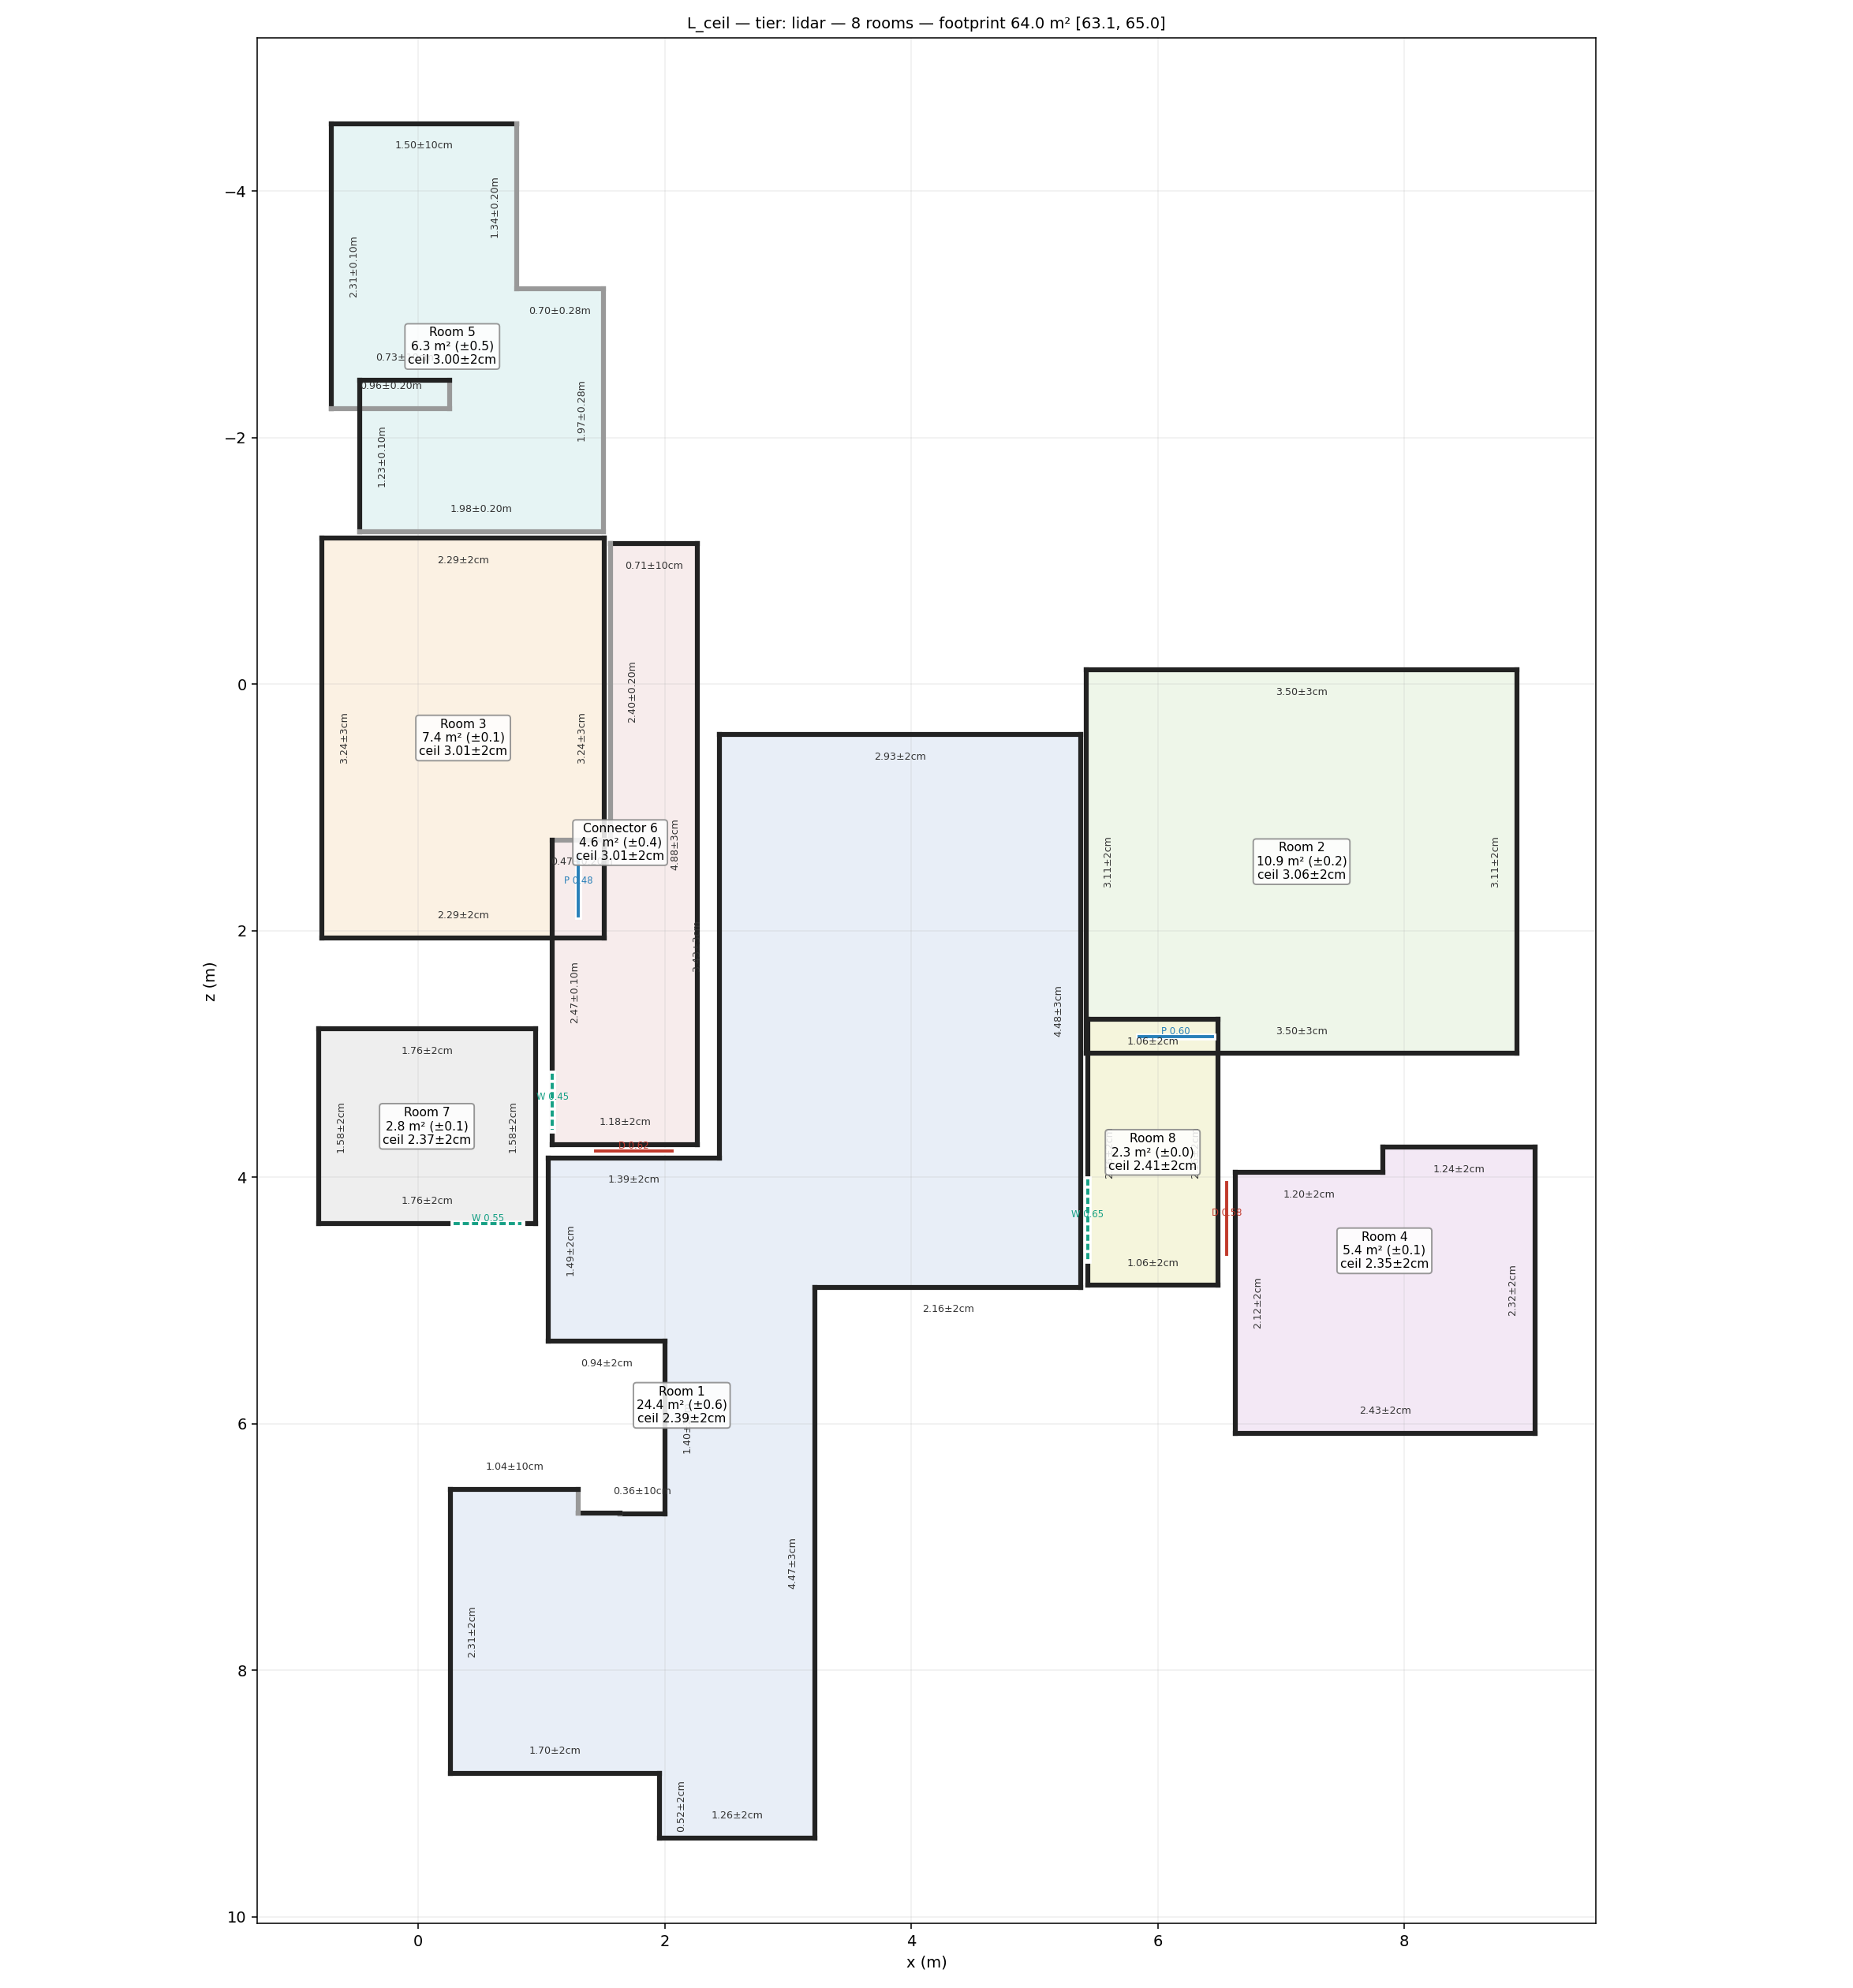

In [7]:
Image(filename=str(ROOT / "benchmark/runs/main/L_ceil_plan.png"), width=850)

**LiDAR, single_room capture:**

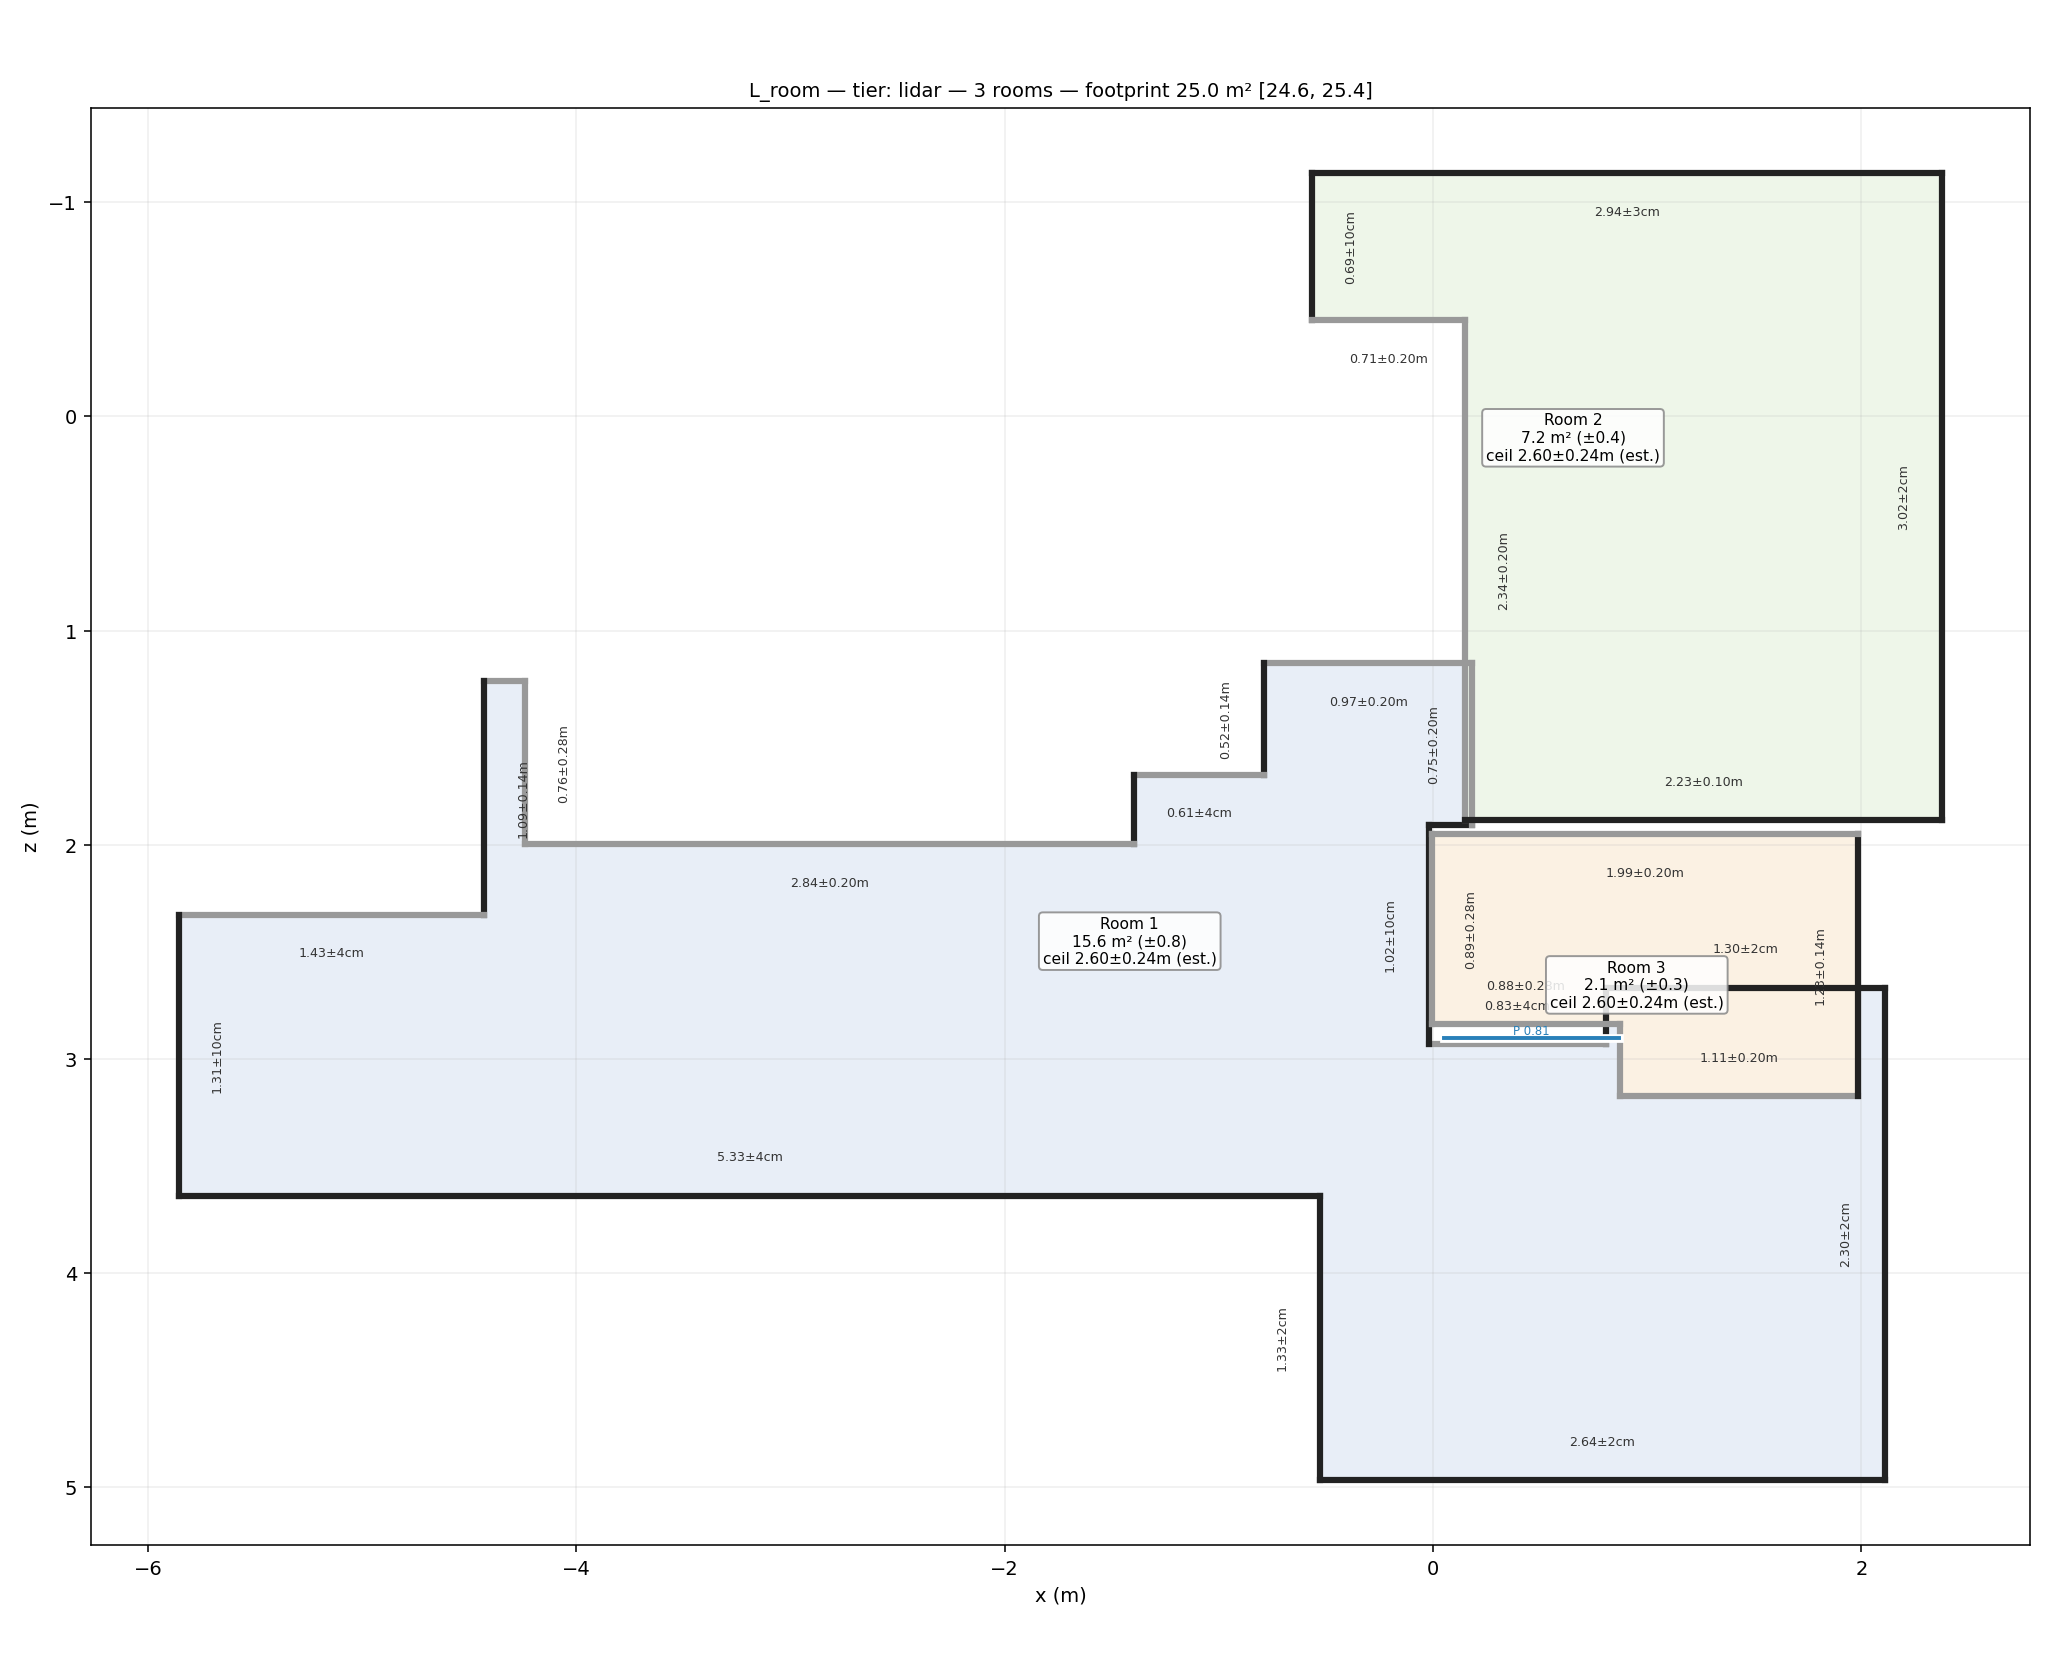

In [8]:
Image(filename=str(ROOT / "benchmark/runs/main/L_room_plan.png"), width=750)

**Video tier, single_room (same capture, RGB only).** Compare it with the plan above to see the scale and tracking error:

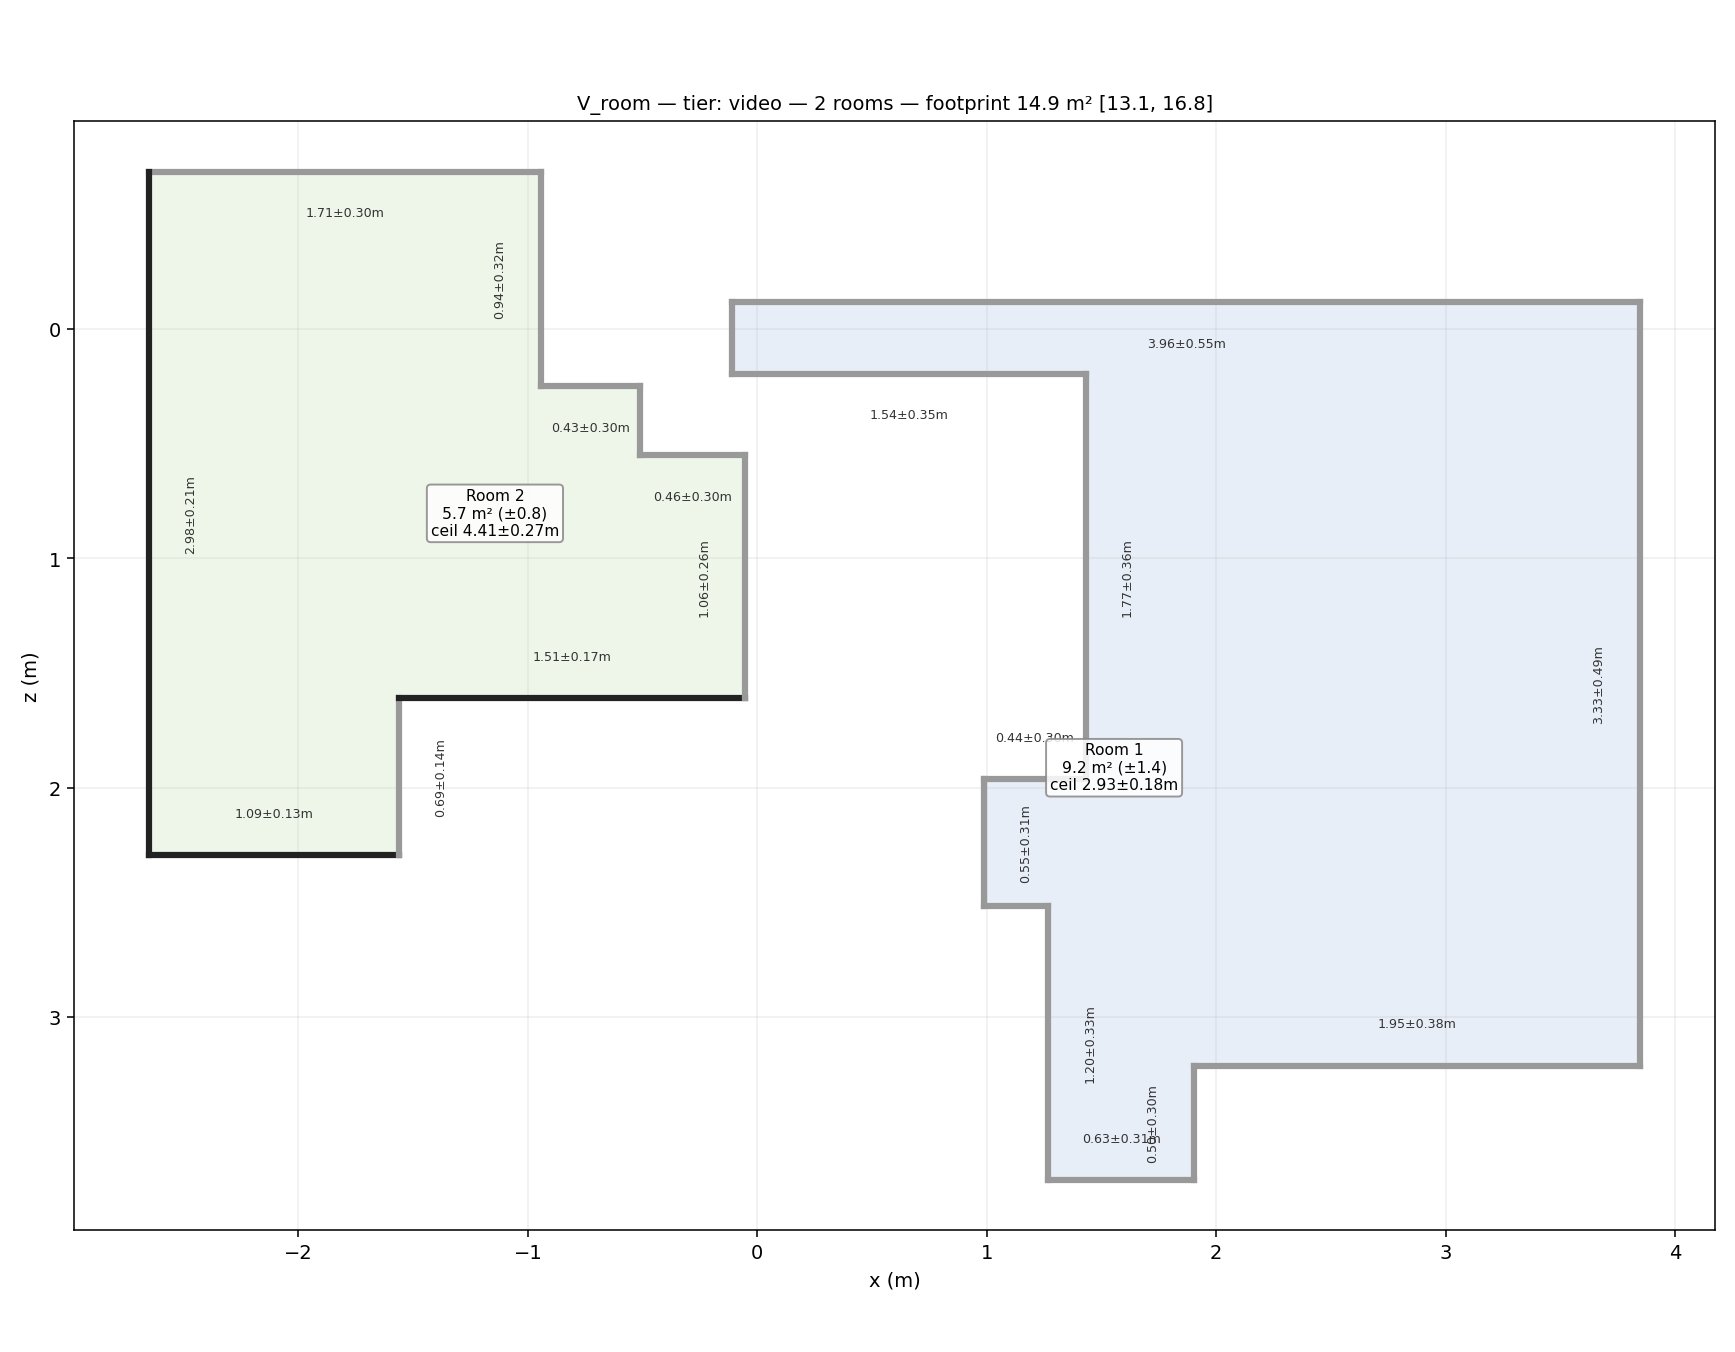

In [9]:
Image(filename=str(ROOT / "benchmark/runs/main/V_room_plan.png"), width=650)

**Photo tier, per-room folders stitched through door photos (`with_ceiling`):**

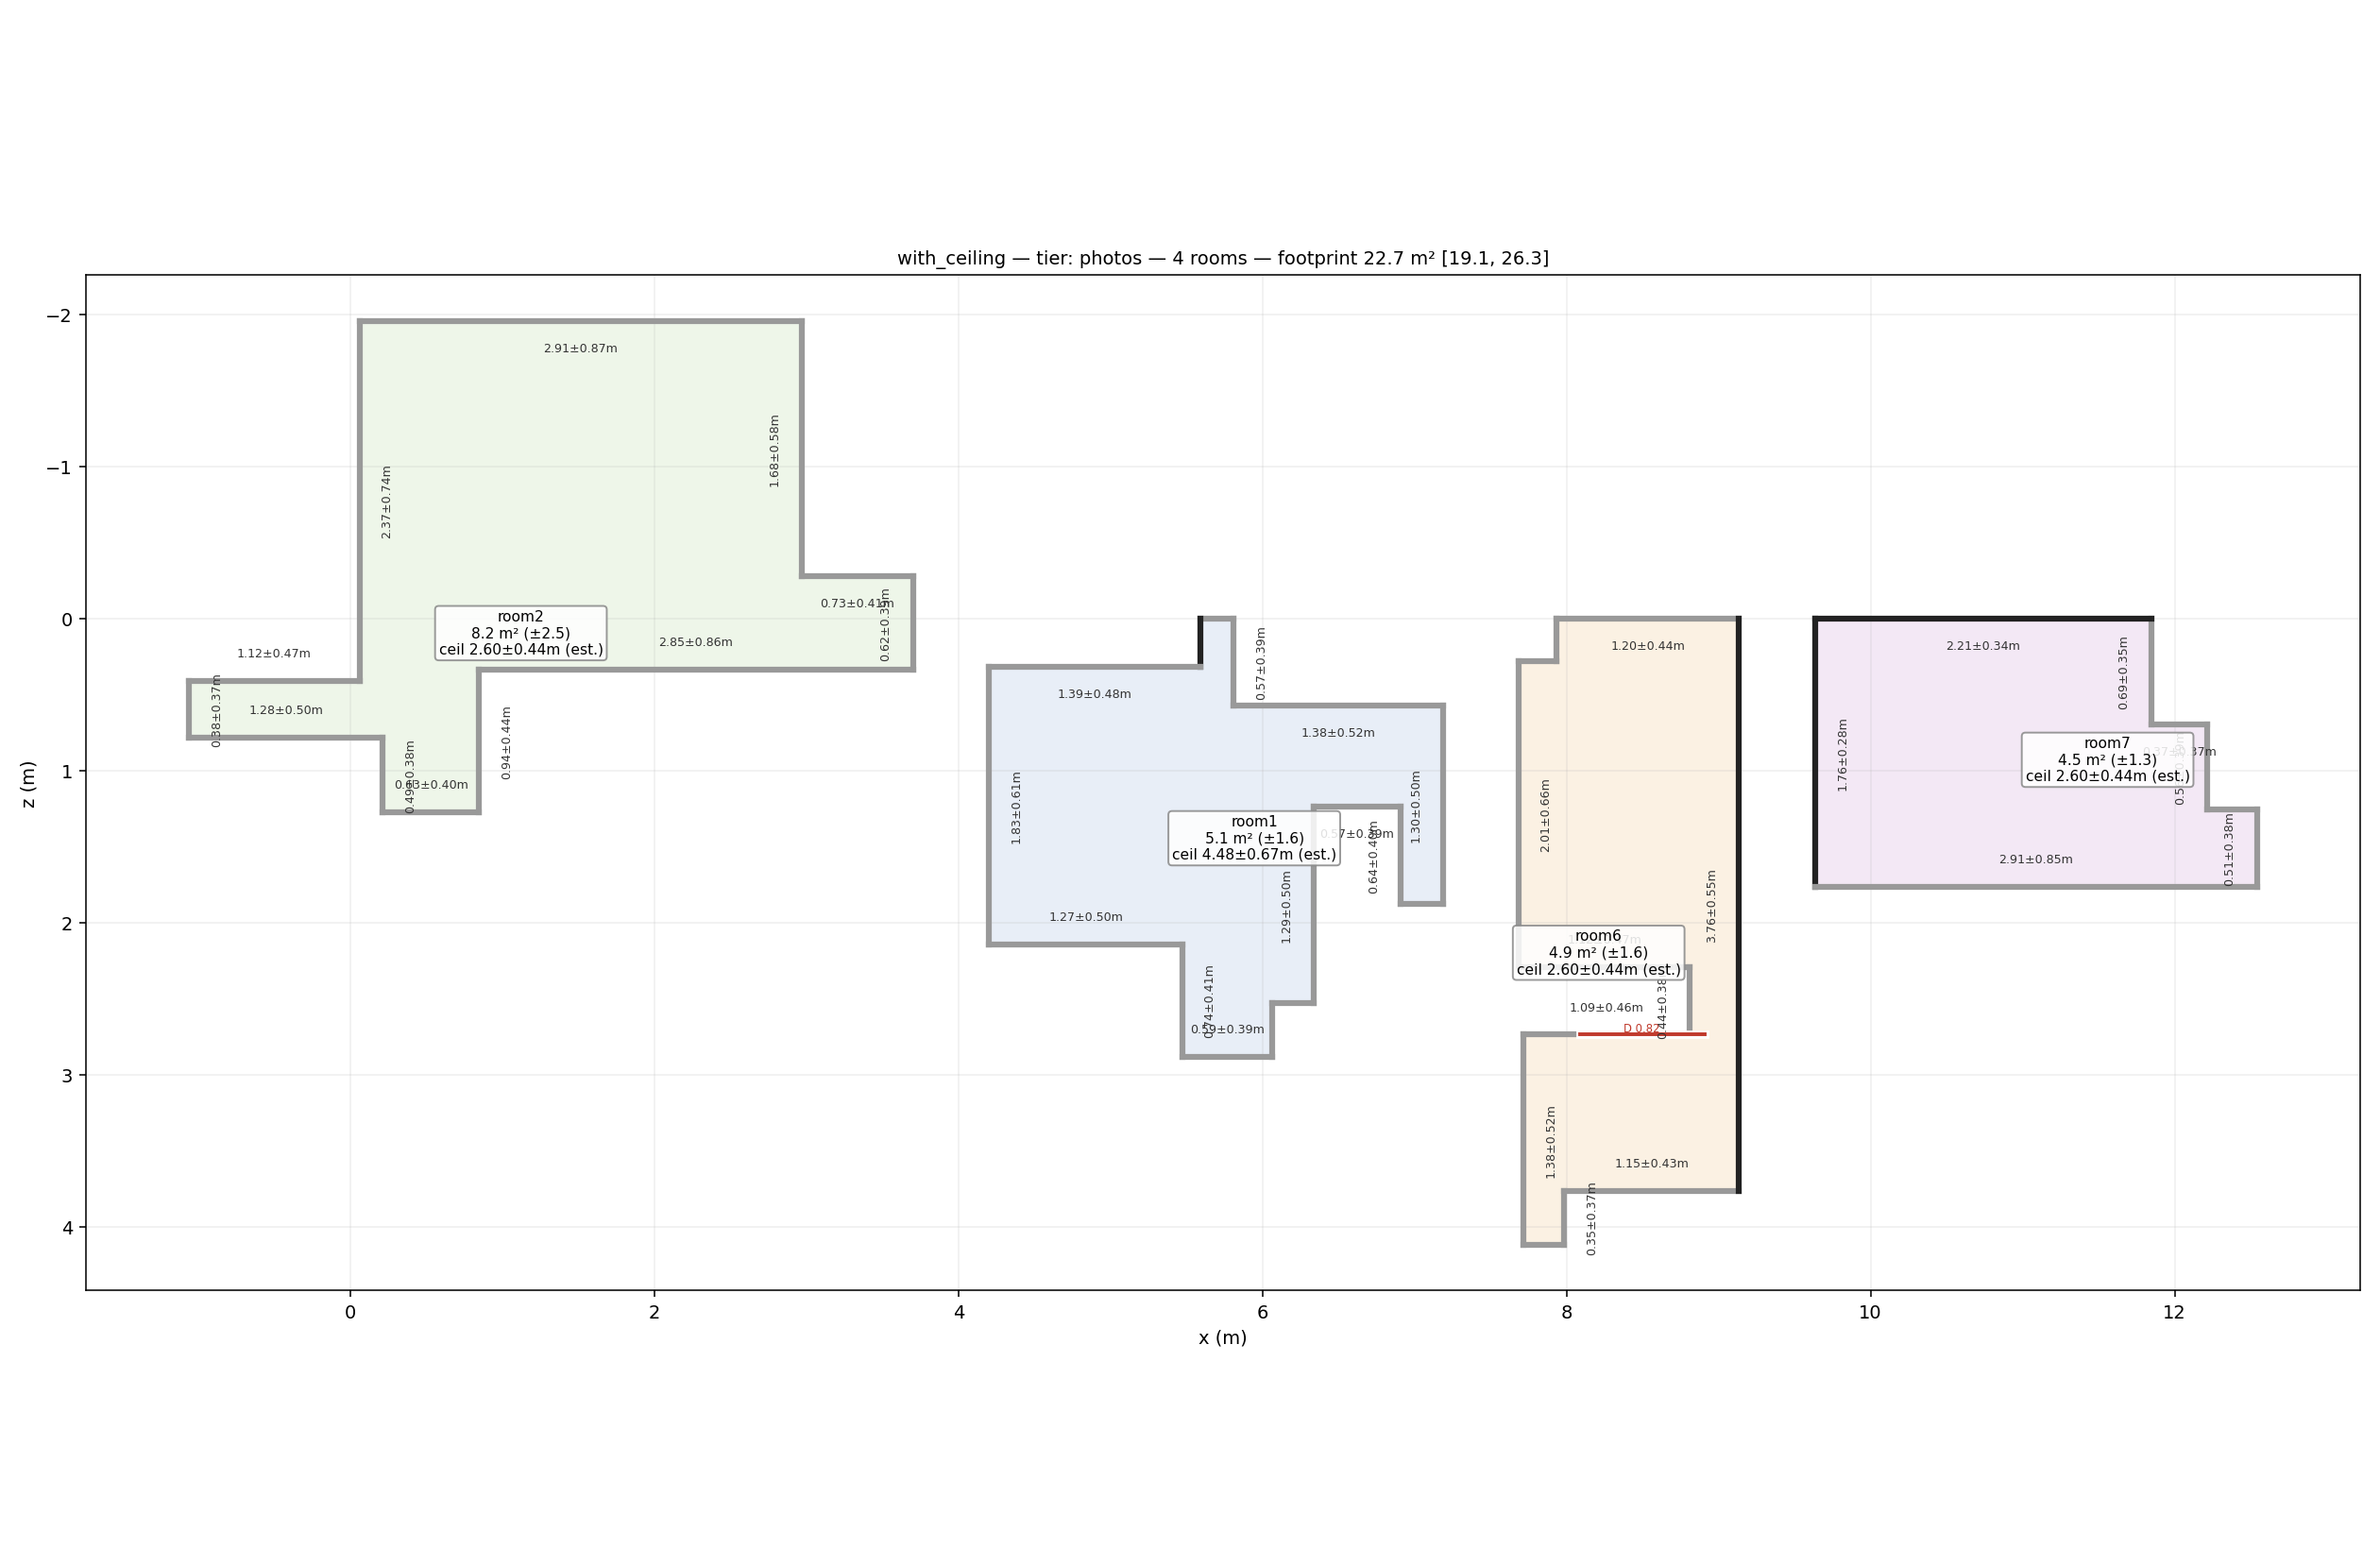

In [10]:
Image(filename=str(ROOT / "benchmark/runs/main/P_ceil_plan.png"), width=750)

### 6.3 Gates (from `benchmark/REPORT.md`)

In [11]:
rep = R["repeatability_lidar_floor_vs_ceil"]
da = R["drift_ablation"]["ceil"]
ps = R["photo_stitch_P_ceil"]
vr = R["video_vs_lidar_V_room"]
gates = [
 ("Repeatability, LiDAR (1 cm / 0.5% per wall)", f"{rep['walls_within_1cm_or_0p5pct']:.0%} of {rep['walls_compared']} walls, median {rep['wall_abs_diff_median_cm']} cm", "FAIL"),
 ("Ceiling height ≤ 1.5 cm vs laser; spread ≤ 1 cm", f"{len(rep['ceiling_pairs'])} room pairs with both ceilings scanned", "NOT MEASURABLE (no laser; floor_only never scanned ceilings)"),
 ("Opening widths ≤ 2 cm on ≥ 85%", f"cross-capture: {rep['openings_matched']} matched", "NOT MEASURED vs laser"),
 ("Drift accountability + ablation", f"{da['loop_closures']} loop closures, ghost-wall area {da['ghost_wall_area_off']} → {da['ghost_wall_area_on']} m²", "DONE"),
 ("Video wall lengths ±3%", f"median error {vr['wall_rel_err_median_pct']}% ({vr['walls_compared']} walls matched)", "FAIL"),
 ("Photo whole-property stitch (adjacency, no overlap, ±8%)", f"{ps['rooms_recovered']}/{ps['room_folders']} rooms, adjacency P={ps['adjacency_precision']} R={ps['adjacency_recall']}, overlaps {len(ps['overlaps'])}, footprint {ps['footprint_err_pct']}%", "FAIL"),
 ("Head-to-head vs consumer app (≥ 70% beat/tie)", "no iPhone, no app scan", "NOT DONE"),
]
pd.DataFrame(gates, columns=["gate", "measured", "status"])

,gate,measured,status
0,"Repeatability, LiDAR (1 cm / 0.5% per wall)","0% of 10 walls, median 23.2 cm",FAIL
1,Ceiling height ≤ 1.5 cm vs laser; spread ≤ 1 cm,0 room pairs with both ceilings scanned,NOT MEASURABLE (no laser; floor_only never sca...
2,Opening widths ≤ 2 cm on ≥ 85%,cross-capture: 1 matched,NOT MEASURED vs laser
3,Drift accountability + ablation,"17 loop closures, ghost-wall area 14.737 → 13....",DONE
4,Video wall lengths ±3%,median error 59.06% (1 walls matched),FAIL
5,"Photo whole-property stitch (adjacency, no ove...","4/7 rooms, adjacency P=1.0 R=1.0, overlaps 0, ...",FAIL
6,Head-to-head vs consumer app (≥ 70% beat/tie),"no iPhone, no app scan",NOT DONE


### 6.4 Repeatability (LiDAR, same tier, two captures)

In [12]:
rows = []
for k, v in R.items():
    if k.startswith("repeatability"):
        rows.append(dict(pair=k.replace("repeatability_lidar_", ""), plan_iou=v["plan_iou"], rooms_matched=v["matched_rooms"],
                         walls=v["walls_compared"], within_gate=v["walls_within_1cm_or_0p5pct"],
                         median_cm=v["wall_abs_diff_median_cm"], p90_cm=v["wall_abs_diff_p90_cm"]))
pd.DataFrame(rows)

,pair,plan_iou,rooms_matched,walls,within_gate,median_cm,p90_cm
0,floor_vs_ceil,0.751,3,10,0.0,23.20,37.35
1,room_vs_ceil,0.320,1,3,0.0,55.67,112.73
2,floor_vs_ceil_NO_DRIFT,0.791,8,20,0.0,17.58,68.70


**How to read this.**
- Wall *planes* repeat to about 3 cm median between captures (measured in the fix loop, §7).
- Wall *lengths* are corner-to-corner, so they differ whenever the two captures split rooms differently or one capture never saw a wall.
- The two "repeat" captures are two different walks (one floor-only, one with ceilings), not the same protocol twice. That is the strongest reason the gate fails.

### 6.5 Drift ablation: poses as-is vs pose-graph corrected

In [13]:
rows = [dict(capture=c, footprint_off=v["footprint_off"], footprint_on=v["footprint_on"], rooms_off=v["rooms_off"],
             rooms_on=v["rooms_on"], ghost_wall_off_m2=v["ghost_wall_area_off"], ghost_wall_on_m2=v["ghost_wall_area_on"],
             loop_closures=v["loop_closures"], mean_corr_m=round(v["mean_correction_m"], 3), max_corr_m=round(v["max_correction_m"], 3))
        for c, v in R["drift_ablation"].items()]
pd.DataFrame(rows)

,capture,footprint_off,footprint_on,rooms_off,rooms_on,ghost_wall_off_m2,ghost_wall_on_m2,loop_closures,mean_corr_m,max_corr_m
0,floor,59.0705,67.325,8,5,12.643,12.470,18,0.458,0.852
1,ceil,64.8750,64.020,9,8,14.737,13.761,17,0.114,0.231


**Ghost-wall area** is the area of 2.5 cm plan cells holding wall returns. Drift doubles walls, which inflates it, so lower is better.
- **`with_ceiling`:** correction works, ghost-wall area down about 7%.
- **`floor_only`:** this is a **known regression**. With the speed settings chosen at 15:40 for the live run (about 700 frames, 4 loop candidates), the optimiser accepted bad loop closures. That gives a 0.46 m mean correction and merged rooms. In the development configuration (all frames, 8 candidates) the same method gave 37 closures and −8% ghosting on `with_ceiling`.
- **Next step:** stricter loop-closure acceptance, and rejecting corrections over 0.3 m.
- **Also caught earlier:** a speed-up dropped loop closures from 38 to 4 and made ghosting *worse* than no correction. The ghost metric stored in every run's JSON is what exposed it.

### 6.6 Cross-tier agreement and calibration (reference = LiDAR tier of the same capture)

In [14]:
rows = []
for k, v in R.items():
    if k.startswith(("video_vs", "photos_vs")):
        rows.append(dict(run=k, plan_iou=v.get("plan_iou"), walls_compared=v.get("walls_compared"),
                         median_rel_err_pct=v.get("wall_rel_err_median_pct"), within_gate=v.get("wall_within_gate"),
                         ci95_coverage=v.get("ci95_coverage"), footprint_err_pct=v.get("matched_footprint_err_pct")))
pd.DataFrame(rows)

,run,plan_iou,walls_compared,median_rel_err_pct,within_gate,ci95_coverage,footprint_err_pct
0,video_vs_lidar_V_room,0.462,1,59.06,0.0,0.0,-34.58
1,video_vs_lidar_V_floor,0.177,0,NaN,NaN,NaN,NaN
2,video_vs_lidar_V_ceil,0.280,0,NaN,NaN,NaN,NaN
3,photos_vs_lidar_P_ceil,0.244,0,NaN,NaN,NaN,NaN


**Honest reading.**
- The video and photo tiers run end to end and produce plans, but their geometry is far from the LiDAR reference:
  - plan overlap with the reference (IoU) is 0.18–0.46;
  - few walls register well enough to be matched at all;
  - where they do, the error is tens of percent.
- **The intervals are not calibrated:** coverage is 0% where measurable, so these tiers are currently *confident garbage* by the brief's own definition.
- **Root cause:** monocular metric scale. The model's per-frame scale wanders 0.3–1.4×, and chaining it over long clips accumulates error.
- **The fix direction is clear:** a learned multi-view reconstruction model (VGGT/MASt3R-class) for poses and consistent scale. That needs a GPU we couldn't use here.

### 6.7 Photo-tier whole-property stitch

In [15]:
ps = R["photo_stitch_P_ceil"]
display(pd.Series({k: ps[k] for k in ("room_folders", "rooms_recovered", "adjacency_ref", "adjacency_found",
                                      "adjacency_precision", "adjacency_recall", "overlaps", "footprint_ref_m2",
                                      "footprint_tier_m2", "footprint_err_pct", "gate_pass")}).to_frame("value"))

,value
room_folders,7
rooms_recovered,4
adjacency_ref,"[[room1, room6]]"
adjacency_found,"[[room1, room6]]"
adjacency_precision,1.0
adjacency_recall,1.0
overlaps,[]
footprint_ref_m2,42.62
footprint_tier_m2,22.74
footprint_err_pct,-46.65


- The stitching logic itself (door photos → room placement) produced correct adjacency with no overlaps for the rooms it recovered.
- The gate fails because **3 of 7 rooms didn't register**: too few matches between soft, frame-grabbed images of white walls.
- Real iPhone stills, which are sharper, would match better, but we couldn't capture any (§2).

### 6.8 Damage: synthetic injection test (the data has no real damage)

In [16]:
display(Markdown(f"Painted onto wall `{SYN['wall']}`. Truth: " + "; ".join(f"**{t['cls']}** {t['w']:.2f} × {t['h']:.2f} m" for t in SYN['truth'])))
pd.DataFrame(SYN["detected"])

Painted onto wall `R2-W11-S`. Truth: **water_stain** 0.40 × 0.25 m; **crack** 0.41 × 0.29 m

,id,cls,surface,w,h,w_ci,h_ci,frames
0,D1,crack,R2-W11-S,0.391,0.267,"[0.3653, 0.4169]","[0.2416, 0.2931]",7


In [17]:
pd.DataFrame(SYN["concealed"]).assign(scope_items=len(SYN["scope"]))

,rule,surface,scope_items
0,R4,R2-W11-S,3


**Results:**
- The **crack** was found on the right wall, measuring 0.391 × 0.267 m against a true 0.410 × 0.287 m (about 2 cm error), in 7 views. Rule R4 fired, and the scope items were generated.
- The **water stain was missed:** a recall gap we report rather than tune away.
- **Zero false detections** on the undamaged apartment.

**The synthetic test found two real detector bugs:**
- the stain background filter (31 px) was smaller than a real stain, so the stain cancelled itself out;
- the crack thinness limit rejected a 2 px anti-aliased crack.

Both are fixed and in the history (`73be2dd`).

### 6.9 Timing (seconds; 12-thread laptop CPU, no GPU; afternoon runs were throttled)

In [18]:
pd.DataFrame(R["timing_s"]).T.fillna("")

,load,drift,fuse,plan,damage,total,decode,depth_model,tracking,rooms,stitch
L_room,15.54,243.43,143.17,4.67,96.54,504.35,,,,,
L_floor,14.63,203.48,22.3,4.03,43.48,288.69,,,,,
L_ceil,3.7,664.97,57.45,5.25,207.51,939.91,,,,,
L_floor_nodrift,16.56,0.0,155.46,24.24,177.41,378.94,,,,,
L_ceil_nodrift,3.24,0.0,75.8,31.44,301.51,417.68,,,,,
V_room,,46.43,20.25,1.41,7.67,229.74,27.49,94.85,31.2,,
V_floor,,76.96,97.87,2.73,12.11,2798.85,138.29,2428.39,41.86,,
V_ceil,,176.07,126.07,2.98,21.14,554.39,175.88,16.31,35.39,,
P_ceil,,,,,,548.45,,,,548.34,0.01


- **LiDAR:** most of the time goes to drift correction.
- **Video:** dominated by the depth model, about 1.3 s per keyframe on CPU. It's cached after the first run, so `V_ceil`'s depth stage took 16 s on re-run against 2,428 s for uncached `V_floor`.
- **GPU:** a CUDA PyTorch build is picked up automatically and would cut this by roughly 10–20×.

## 7. Fix loop (Part 4): worst gate → hypothesis → shipped fix → before/after

**Gate:** LiDAR repeatability, `floor_only` vs `with_ceiling`.

**Before:** 0.0% of walls within 1 cm / 0.5%, median 24.1 cm.

| Step | Hypothesis | Evidence | Outcome |
|---|---|---|---|
| H1 | Walls are fitted to furniture faces (sofa backs, fridge fronts) | plane spacing inside rooms differed by a median of 11 cm | Fit walls only above 1.5 m → **worse** (median 41 cm). Only 19% of edges moved, and `floor_only` rarely saw that height. **Rejected.** |
| H2 | Wall position is set by where the occupancy mask happens to stop, and corners are unstable | overlay: outlines up to 40 cm inside visible walls; **plane positions repeat to about 3 cm while lengths differ by 23 cm** | Coverage-based plane snap + rectangle snap + back-face barrier. **Shipped.** |

All variants below use the same fused clouds, so only the wall fit differs (`scripts/fixloop_eval.py`):

In [19]:
pd.DataFrame([dict(variant=m, plan_iou=FL[m]["plan_iou"], walls=FL[m]["walls_compared"],
                   within_gate=FL[m]["walls_within_1cm_or_0p5pct"], median_cm=FL[m]["wall_abs_diff_median_cm"],
                   p90_cm=FL[m]["wall_abs_diff_p90_cm"]) for m in ("legacy", "high", "planes")])

,variant,plan_iou,walls,within_gate,median_cm,p90_cm
0,legacy,0.705,25,0.000,24.13,66.16
1,high,0.707,21,0.048,41.18,81.05
2,planes,0.744,21,0.143,24.11,50.76


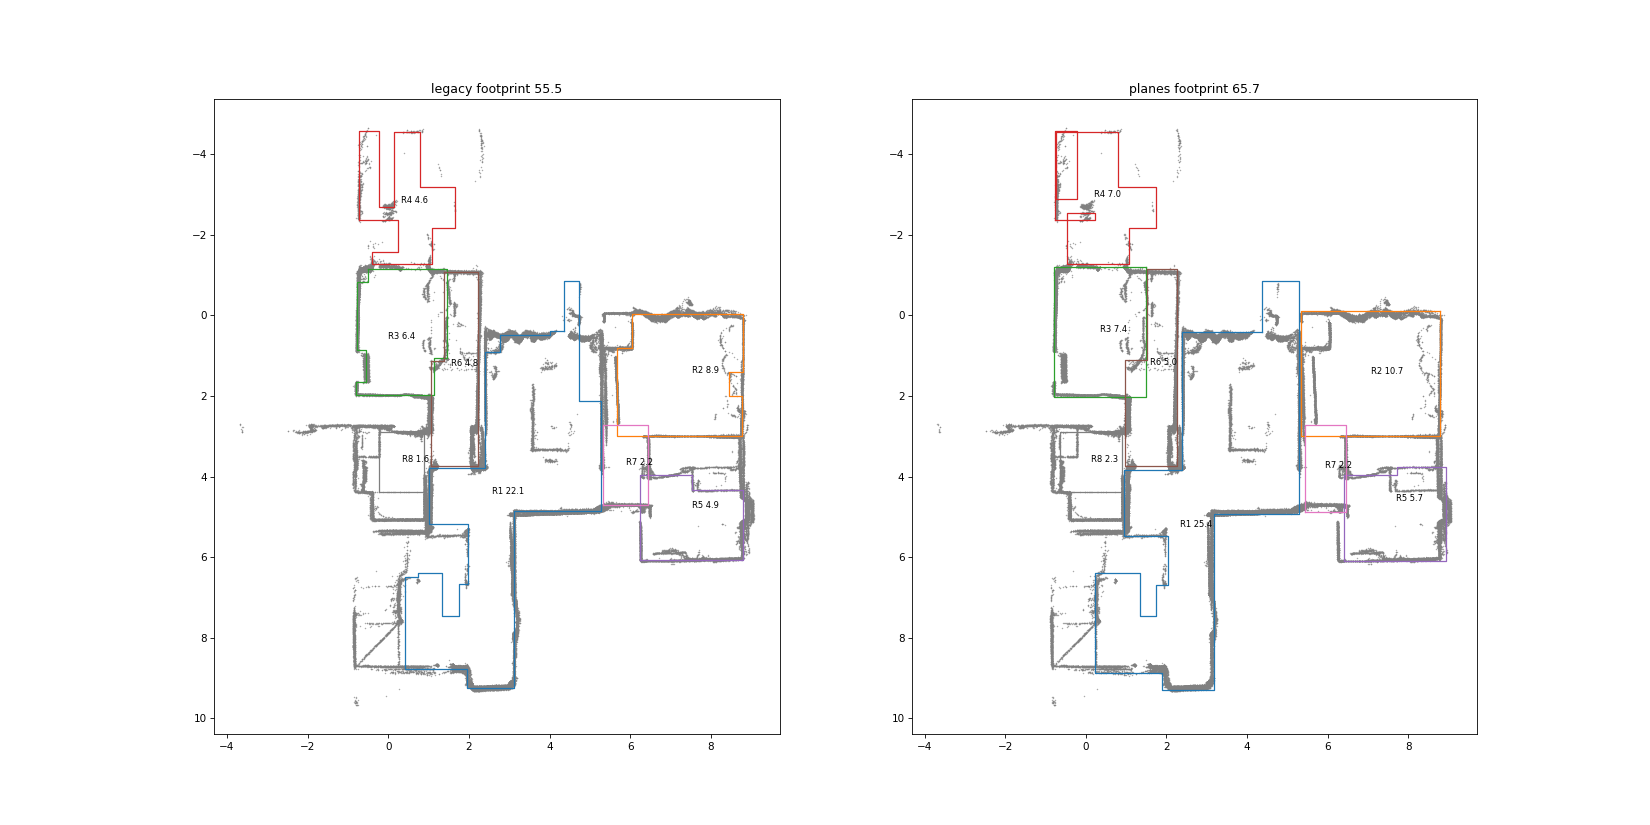

In [20]:
Image(filename=str(ROOT / "docs/img/fixloop_plan_legacy_vs_planes.png"), width=950)

**Verdict.**
- The within-gate share moved 0% → 14.3% and the p90 66 → 51 cm. **The median did not move, and the gate still fails.**
- On the plan, rooms now sit on their walls (right) instead of up to 40 cm inside them (left). This matters most for the walk-in test, where a laser measures wall to wall.
- *Why it fell short:* the residual is coverage (walls one capture never saw) and different room splits between two different walks, not wall fitting.

**Disclosures:**
- The 0.5 coverage threshold was chosen on this same pair; the sensitivity table is in `docs/FIX_LOOP.md`.
- **No numeric prediction was written down before shipping.** That is a process gap, stated rather than back-dated.

## 8. What is not done, and why

| Item from the PDF | Why not | What would close it |
|---|---|---|
| Head-to-head vs Polycam/magicplan, 2 rooms, ≥ 70% beat/tie (10% of score) | No iPhone | 30 min with a borrowed iPhone Pro: Polycam (free) + Stray Scanner + tape. `propscan/compare.py` already scores any two plans. |
| Laser/tape ground truth on everything | Not supplied; no access to the sample apartment | Tape-measure any space captured with a borrowed phone |
| Our own benchmark captures (multi-room, staged damage across two classes, same-protocol repeat, real photo folders) | No iPhone | Same borrowed-phone session |
| Opening-width and ceiling-height gates vs laser | No ground truth | As above |
| Video and photo tiers within ±3% / ±8% and calibrated | Monocular scale on CPU-only hardware | A multi-view learned reconstruction model on a GPU; recalibrate σ against measurements |
| Real damage recall | No damaged room in the data | A staged-damage capture |
| Route 1 (own iOS app) | No Mac, Xcode or iPhone | Not needed; Route 2 is permitted |

## 9. Known failure modes
- **Video scale:** monocular metric scale drifts on long clips, so video results are not reliable measurements yet.
- **Photo registration on white walls:** frame-grabbed stills register partially. Missing rooms are reported, never invented.
- **Drift speed configuration:** see §6.5 (`floor_only` over-correction).
- **Mirrors and glass:** mirrors are rejected by the reflection test. Glass shower screens can still split a bathroom. Windows facing far or dark exteriors return nothing and are missed.
- **Unscanned ceilings:** given as a prior, flagged `observed: false`.
- **Low light and wet-looking surfaces:** low light raises damage false positives from shadows. Floors are not analysed for damage, so wet-look floors are out of scope.
- **Multi-storey:** not supported. A single floor level is assumed.

## 10. Defence notes: likely questions and answers

**Q: Why Route 2 and not your own app?**
No Mac, Xcode or iPhone, and Route 2 is explicitly allowed. Stray Scanner exports exactly what the LiDAR tier needs: depth, confidence, ARKit poses and intrinsics. The protocol fits on one page and uses only free App Store apps.

**Q: Why one engine for all tiers?**
Because the tiers differ only in where depth and poses come from. A shared engine means one set of bugs, consistent outputs, and intervals that differ only through the error budget, not through different algorithms.

**Q: How did you know Stray's pose convention?**
I tested it. The ARKit→OpenCV flip smears the floor over 2 m; the raw pose gives a 1 cm floor bin with 6% of all points.

**Q: Why is video scale chained instead of using the model's metric output?**
Measured against LiDAR, the model's scale per frame wanders 0.3–1.4× within seconds while its shape stays within about 3%. Trusting one frame's scale is wrong; chaining keeps it consistent, and the clip-wide average anchors it.

**Q: Why the essential matrix in the photo tier?**
PnP needs accurate per-point depth, which monocular depth doesn't give: 2 of 11 photos registered. The essential matrix doesn't need depth for rotation and direction, and scale comes from a median ratio: 9 of 11 registered.

**Q: What does drift correction actually do, and how do you know it works?**
A fragment pose graph with ICP loop closures, keeping yaw and translation only. Evidence: the ghost-wall area metric in every run, plus the on/off ablation. It also caught a regression of my own (38 → 4 loop closures).

**Q: How do you reject mirrors?**
Reflect the "through-the-wall" returns back across the plane. If more than 50% land on real geometry, the gap is a reflection, not an opening.

**Q: Why are your repeatability numbers so bad?**
The two captures are different walks with different coverage. Wall planes agree to about 3 cm; lengths don't, because corners come from neighbouring walls and the room split. The fix loop measured that decomposition.

**Q: Why should we trust any of your numbers without ground truth?**
I don't claim accuracy against a laser anywhere. I claim repeatability, cross-tier agreement and synthetic recovery, and I label the rest NOT MEASURED. Every number regenerates from raw data with one script.

**Q: Your fix didn't pass the gate. Why ship it?**
- The diagnosis was right: plane positions repeat, corners don't.
- The fix moves walls onto the real wall faces, which is what a laser measures in the walk-in test.
- The first hypothesis was tested and rejected with evidence, and that's documented too.

**Q: What would you do with one more day and an iPhone?**
1. Capture and tape-measure 3 rooms plus a Polycam scan (closes Part 3 and the ground-truth gates).
2. Tighten loop-closure acceptance.
3. Calibrate σ per tier against the measurements.
4. Move video and photos to a multi-view learned reconstruction model on a GPU.

## 11. How to reproduce

```bash
pip install -r requirements.txt
python scripts/fetch_weights.py                     # ~100 MB depth model (video/photo tiers)
# put the three sample zips in "sample data/"
python -m propscan run "sample data/single_room.zip" -o out/      # one command per capture
python scripts/benchmark.py                          # every run + scores -> benchmark/results_main.json
python scripts/make_report.py                        # -> benchmark/REPORT.md
python scripts/fixloop_eval.py --evidence            # fix-loop before/after
python scripts/synthetic_damage_test.py "sample data/single_room.zip"
python scripts/make_report_notebook.py               # rebuilds this notebook
```

| Document | Content |
|---|---|
| `README.md` | setup and layout |
| `docs/CAPTURE_PROTOCOL.md` | one-page capture guide |
| `docs/DEVICE_MATRIX.md` | which tier runs on which phone |
| `docs/COMPLIANCE.md` | requirement → file → artefact → status |
| `docs/TECHNICAL_REPORT.md` | technical report (≤ 6 pages) |
| `docs/FIX_LOOP.md` | fix loop |
| `docs/MODELS.md` | model and tool disclosure |
| `benchmark/REPORT.md` | all tables |

## 12. Build timeline (commit history)

| Time (IST) | Commit | What |
|---|---|---|
| 10:50 | `ece9358` | Skeleton + Stray loader (pose convention verified) |
| 11:12 | `7aefe6c` | Geometry engine, drift pose graph, renderer, CLI |
| 12:09 | `46984a7` | Video tier (monocular depth, adaptive keyframes, scale chaining) |
| 12:34 | `100902b` | Photo tier (essential-matrix registration, door-photo stitching) |
| 12:42 | `fafc711` | Damage, concealed-damage rules, scope |
| 13:27 | `cf26c78` | Benchmark harness; caught and fixed the drift regression |
| 14:15 | `903e9a8` | Fix loop: H1 rejected, H2 tested |
| 14:24 | `1cefcd6` | Fix loop: rectangle snap + coverage |
| 15:08 | `73be2dd` | Back-face barrier; detector bugs found by the synthetic test |
| 15:17 | `6b9a4d1` | Docs with final fix-loop numbers |
| 15:40 | `268ff97`, `d535f36` | Speed settings for the live run; JSON schema |
| 17:33 | `112ff5b` | Final benchmark, report, device matrix, compliance statuses |

AI coding tools (Claude) were used throughout, as the brief allows. Every design decision above is written down with the evidence that drove it, so it can be defended with tools closed.